Sequential Agent

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [3]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence."""

    state["final"] = f"Hi {state["name"]}!"
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence."""

    state["final"] += f" You are {state["age"]} years old."
    return state

In [4]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node) 

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.set_finish_point("second_node")

app = graph.compile()

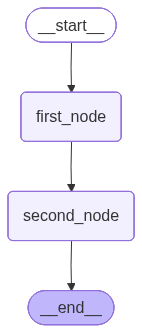

In [5]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({"name": "Alice", "age": "30"})

In [8]:
result

{'name': 'Alice', 'age': '30', 'final': 'Hi Alice! You are 30 years old.'}